# 1. One-Hop Message Passing with a GCN

## (a) Set up a toy graph and features


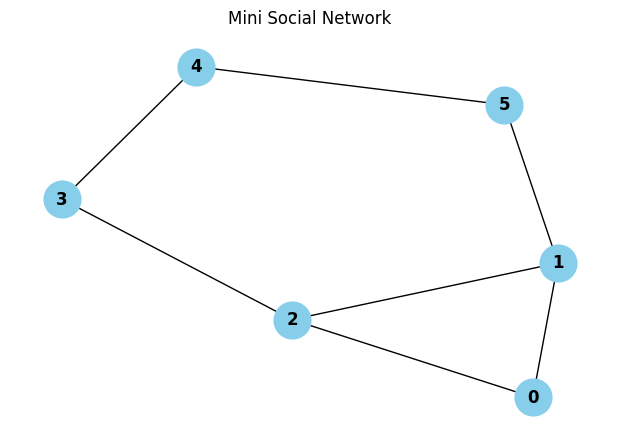

Adjacency matrix:
[[0. 1. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0. 1.]
 [1. 1. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 1. 0. 1.]
 [0. 1. 0. 0. 1. 0.]]

Node feature matrix X:
[[1.  0. ]
 [0.9 0.1]
 [0.8 0.2]
 [0.2 0.9]
 [0.1 1. ]
 [0.3 0.8]]


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create a small undirected graph representing a friendship network
G = nx.Graph()

edges = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5),
    (1, 5),
    (0, 2)
]

G.add_edges_from(edges)

# 2. Visualize the graph
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=700,
    font_size=12,
    font_weight="bold"
)

plt.title("Mini Social Network")
plt.show()

# 3. Node features
# Each user has two interest scores: [tech_interest, art_interest]
X = np.array([
    [1.0, 0.0],   # user 0: strongly tech-oriented
    [0.9, 0.1],   # user 1: mostly tech-oriented
    [0.8, 0.2],   # user 2: mostly tech-oriented
    [0.2, 0.9],   # user 3: strongly art-oriented
    [0.1, 1.0],   # user 4: strongly art-oriented
    [0.3, 0.8]    # user 5: mostly art-oriented
])

# 4. Adjacency matrix
A = nx.to_numpy_array(G)

print("Adjacency matrix:")
print(A)

print("\nNode feature matrix X:")
print(X)

The graph has 6 users. Users `0`, `1`, and `2` are more tech-oriented, while users `3`, `4`, and `5` are more art-oriented. Friendships connect them.


## (b) Implement a one-layer GCN


In [2]:
def relu(Z):
    return np.maximum(0, Z)


def gcn_layer(X, A, W):
    """
    Performs one GCN layer:

    H = ReLU(D_tilde^(-1/2) A_tilde D_tilde^(-1/2) X W)

    Parameters:
    X : numpy array
        Node feature matrix of shape (num_nodes, num_features)
    A : numpy array
        Adjacency matrix of shape (num_nodes, num_nodes)
    W : numpy array
        Weight matrix of shape (num_features, output_features)

    Returns:
    H : numpy array
        Updated node embeddings
    """

    # Number of nodes
    num_nodes = A.shape[0]

    # Add self-loops
    I = np.eye(num_nodes)
    A_tilde = A + I

    # Degree matrix of A_tilde
    degrees = np.sum(A_tilde, axis=1)
    D_tilde = np.diag(degrees)

    # Compute D^(-1/2)
    D_tilde_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))

    # Normalized adjacency matrix
    A_norm = D_tilde_inv_sqrt @ A_tilde @ D_tilde_inv_sqrt

    # GCN operation
    H = relu(A_norm @ X @ W)

    return H

# Weight matrix
# Input feature dimension = 2
# Output embedding dimension = 2
W = np.array([
    [0.8, 0.2],
    [0.2, 0.8]
])

H = gcn_layer(X, A, W)

print("Updated node embeddings H:")
print(H)

Updated node embeddings H:
[[0.67658536 0.23409824]
 [0.70141016 0.40480762]
 [0.68408965 0.42212813]
 [0.40296576 0.61904271]
 [0.34       0.76      ]
 [0.44028627 0.5817222 ]]


## (c) Visualization of the new embeddings


Since each updated embedding has 2 dimensions, we can plot them directly in 2D.


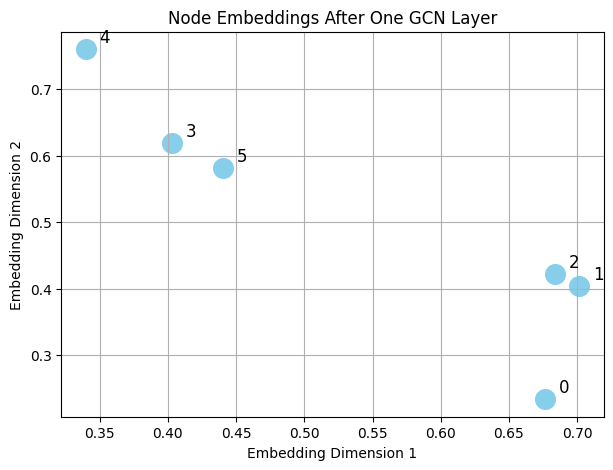

In [3]:
plt.figure(figsize=(7, 5))

for i in range(H.shape[0]):
    plt.scatter(H[i, 0], H[i, 1], s=200, color="skyblue")
    plt.text(H[i, 0] + 0.01, H[i, 1] + 0.01, str(i), fontsize=12)

plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.title("Node Embeddings After One GCN Layer")
plt.grid(True)
plt.show()

We can also compare the original features to the new GCN embeddings.

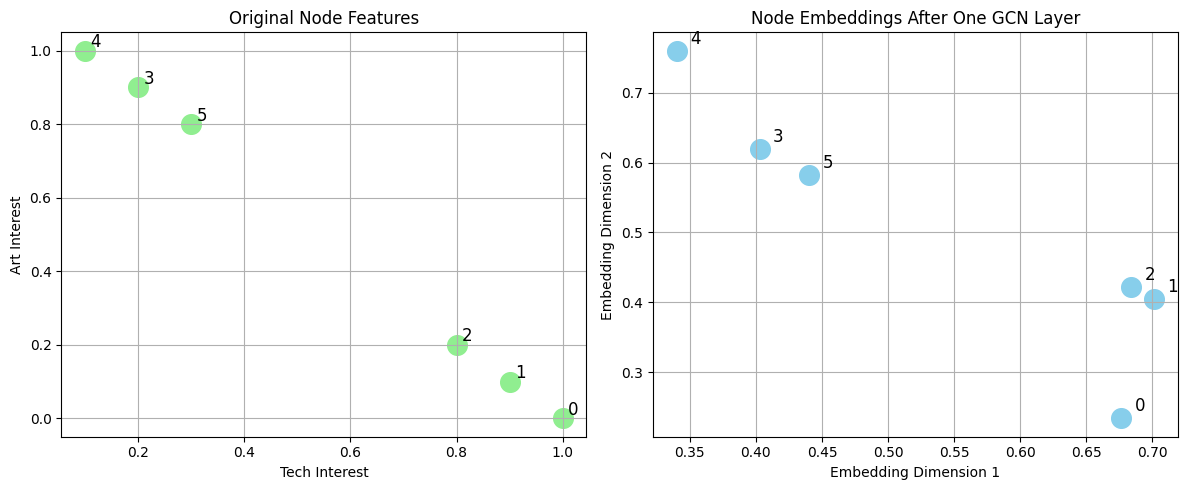

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original features
axes[0].scatter(X[:, 0], X[:, 1], s=200, color="lightgreen")

for i in range(X.shape[0]):
    axes[0].text(X[i, 0] + 0.01, X[i, 1] + 0.01, str(i), fontsize=12)

axes[0].set_xlabel("Tech Interest")
axes[0].set_ylabel("Art Interest")
axes[0].set_title("Original Node Features")
axes[0].grid(True)

# New embeddings
axes[1].scatter(H[:, 0], H[:, 1], s=200, color="skyblue")

for i in range(H.shape[0]):
    axes[1].text(H[i, 0] + 0.01, H[i, 1] + 0.01, str(i), fontsize=12)

axes[1].set_xlabel("Embedding Dimension 1")
axes[1].set_ylabel("Embedding Dimension 2")
axes[1].set_title("Node Embeddings After One GCN Layer")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Observation

After one GCN layer, each node's new representation becomes a mixture of:

1. Its own original features.
2. The features of its immediate neighbors.

As a result, connected users tend to become more similar in the embedding space. For example, users `0`, `1`, and `2` are connected and are all relatively tech-oriented, so their embeddings should appear close together. Users `3`, `4`, and `5` are more art-oriented and connected through friendships, so they should also appear closer together.

However, nodes such as `2` and `3` are connected even though they start with different interests. The GCN will make their representations slightly more similar because they exchange information through the edge between them.

This is the smoothing effect of a GCN.

## (d) Short response


### What happens to node features after one GCN layer?

After one GCN layer, each node updates its feature vector by combining its own features with the features of its immediate neighbors. This is called one-hop message passing because information travels across one edge.

For example, if user `1` is friends with users `0`, `2`, and `5`, then user `1`'s new representation will be influenced by users `0`, `2`, and `5`.

### Why do we add self-loops?

We add self-loops so that each node keeps some of its own information during the update.

Without self-loops, a node would only aggregate information from its neighbors and might lose its own original identity. With self-loops, the GCN uses both:

- the node's own features
- its neighbors' features

So the update is more stable and meaningful.

### What would stacking more layers do?

Stacking more GCN layers allows nodes to receive information from farther away in the graph.

- One GCN layer: information from 1-hop neighbors.
- Two GCN layers: information from 2-hop neighbors.
- Three GCN layers: information from 3-hop neighbors.

However, stacking too many layers can cause over-smoothing. This means that many node embeddings may become too similar, making it hard to distinguish different nodes.

### Where else could GNNs be applied other than social graphs?

GNNs can be used in many domains where data has a graph structure, such as:

- Recommendation systems, such as users connected to products.
- Molecule modeling, where atoms are nodes and chemical bonds are edges.
- Traffic prediction, where intersections or sensors are nodes and roads are edges.
- Knowledge graphs, such as entities connected by relationships.
- Fraud detection, where accounts, transactions, and devices form a graph.
- Citation networks, where papers cite other papers.
- Biological networks, such as protein-protein interaction networks.

In general, GNNs are useful whenever relationships between objects matter.

# 2

## (a) Conceptual setup


For the query token **“chased”**, the most important tokens are likely **“cat”** and **“mouse”**.

- **“cat”** should get high attention because it tells us *who* is doing the chasing.
- **“mouse”** should get high attention because it tells us *what is being chased*.
- The words **“The”** and **“the”** should receive the least attention because they are articles. They help with grammar, but they carry less meaning than the nouns.

In plain language, the model is trying to understand the event described by **“chased”**: who performed the action and who or what received the action.


## (b) Mini-attention table



| Token  | Relevance to “chased” | Why                                                                                      |
|--------|----------------------:|------------------------------------------------------------------------------------------|
| The    |                   Low | It is an article that helps introduce “cat,” but it does not add much meaning by itself. |
| cat    |                  High | It is the subject, the one doing the chasing.                                            |
| chased |                Medium | The token may attend to itself to preserve its own meaning as the action word.           |
| the    |                   Low | It is an article that helps introduce “mouse,” but it has little meaning alone.          |
| mouse  |                  High | It is the object, the thing being chased.                                                |


## (c) Small numeric version



Example attention weights from **“chased”**:

| Token  | Attention weight |
|--------|-----------------:|
| The    |             0.05 |
| cat    |             0.30 |
| chased |             0.10 |
| the    |             0.05 |
| mouse  |             0.50 |

These weights sum to:
$$0.05 + 0.30 + 0.10 + 0.05 + 0.50 = 1.00$$

The weights should sum to **1** because attention weights act like a probability distribution over the tokens. A larger weight means the model is using more information from that token when building the context-aware representation of **“chased.”** If **“mouse”** gets the highest weight, it suggests that the meaning of **“chased”** is strongly shaped by its object: the action is specifically about chasing a mouse.

## (d) Short coding task


In [5]:
tokens = ["The", "cat", "chased", "the", "mouse"]

# Assign attention weights that sum to 1
weights = [0.05, 0.30, 0.10, 0.05, 0.50]

# Print token and weight
for token, weight in zip(tokens, weights):
    print(token, ":", weight)

# Find the most attended token
max_weight = max(weights)
max_index = weights.index(max_weight)
most_attended_token = tokens[max_index]

print("Most attended token:", most_attended_token)
print("Highest attention weight:", max_weight)

The : 0.05
cat : 0.3
chased : 0.1
the : 0.05
mouse : 0.5
Most attended token: mouse
Highest attention weight: 0.5


## (e) 3-5 sentence explanation


Self-attention helps a transformer build meaning by letting each word look at other words in the sentence, not just the words that come before it. For example, **“chased”** becomes more meaningful when it connects to **“cat”** as the subject and **“mouse”** as the object. This is different from simply reading words one at a time because the model can directly compare and combine information from multiple positions in the sentence. As a result, each token gets a context-aware representation based on the whole sentence.


## (f) Optional: Repeat for “cat”


If **“cat”** is the query token, it may pay the most attention to **“chased”** because that tells us what the cat is doing. It may also pay some attention to **“mouse”** because the mouse is involved in the same event.

| Token  | Relevance to “cat” | Why                                                          |
|--------|-------------------:|--------------------------------------------------------------|
| The    |             Medium | It modifies “cat,” helping identify it as a noun phrase.     |
| cat    |             Medium | The token may attend to itself to preserve its own identity. |
| chased |               High | It tells us what action the cat performs.                    |
| the    |                Low | It modifies “mouse,” not “cat.”                              |
| mouse  |             Medium | It is connected to the cat through the chasing event.        |

Example weights from **“cat”**:

| Token  | Attention weight |
|--------|-----------------:|
| The    |             0.10 |
| cat    |             0.20 |
| chased |             0.40 |
| the    |             0.05 |
| mouse  |             0.25 |

Compared with **“chased,”** the token **“cat”** focuses more on the verb **“chased”** because it needs to understand its role in the action. The token **“chased”** focuses heavily on **“cat”** and **“mouse”** because it needs to understand both the subject and object of the action.